# Structured Composition

The previous notebook showed three composition failures. This one shows how gated composition prevents each of them.

The approach has three parts. Separate gate constraints from scoring signals. Cap each scorer's gradient contribution. Monitor component health during training. None of this changes how individual reward components work. We only change how their outputs are combined.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120})
C = {'broken': '#d62728', 'fixed': '#2ca02c', 'format': '#ff7f0e', 'correctness': '#1f77b4', 'style': '#9467bd', 'safety': '#e377c2'}
from src.composition import WeightedSumCompositor, GatedCompositor, run_bandit
from src.scenarios import *

## Gating Eliminates Priority Inversion

When format is a gate, it gets checked first and then forgotten. The optimizer only sees the correctness landscape.

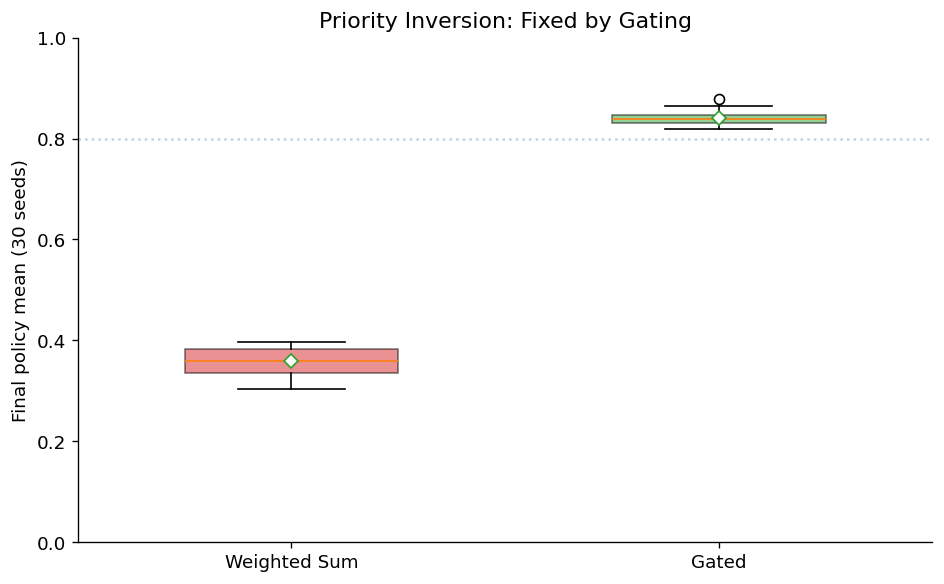

Weighted sum: 0.359 +/- 0.026
Gated:        0.840 +/- 0.013


In [2]:
a_f, g_f = [], []
for seed in range(30):
    a_f.append(run_bandit(WeightedSumCompositor(priority_inversion_broken()), n_steps=2000, seed=seed)['policy_mu'][-1])
    g_f.append(run_bandit(GatedCompositor(priority_inversion_fixed(), monitor=False), n_steps=2000, seed=seed)['policy_mu'][-1])

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([a_f, g_f], positions=[1,2], widths=0.5, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='white', markersize=6))
bp['boxes'][0].set(facecolor=C['broken'], alpha=0.5); bp['boxes'][1].set(facecolor=C['fixed'], alpha=0.5)
ax.axhline(0.8, color=C['correctness'], alpha=0.3, ls=':')
ax.set_xticks([1,2]); ax.set_xticklabels(['Weighted Sum', 'Gated'])
ax.set_ylabel('Final policy mean (30 seeds)'); ax.set_ylim(0,1)
ax.set_title('Priority Inversion: Fixed by Gating')
plt.tight_layout(); plt.show()
print(f"Weighted sum: {np.mean(a_f):.3f} +/- {np.std(a_f):.3f}")
print(f"Gated:        {np.mean(g_f):.3f} +/- {np.std(g_f):.3f}")

## Contribution Caps Prevent Gradient Dominance

Capping each scorer's contribution to (weight * influence_cap) prevents any single component from dominating regardless of its output variance.

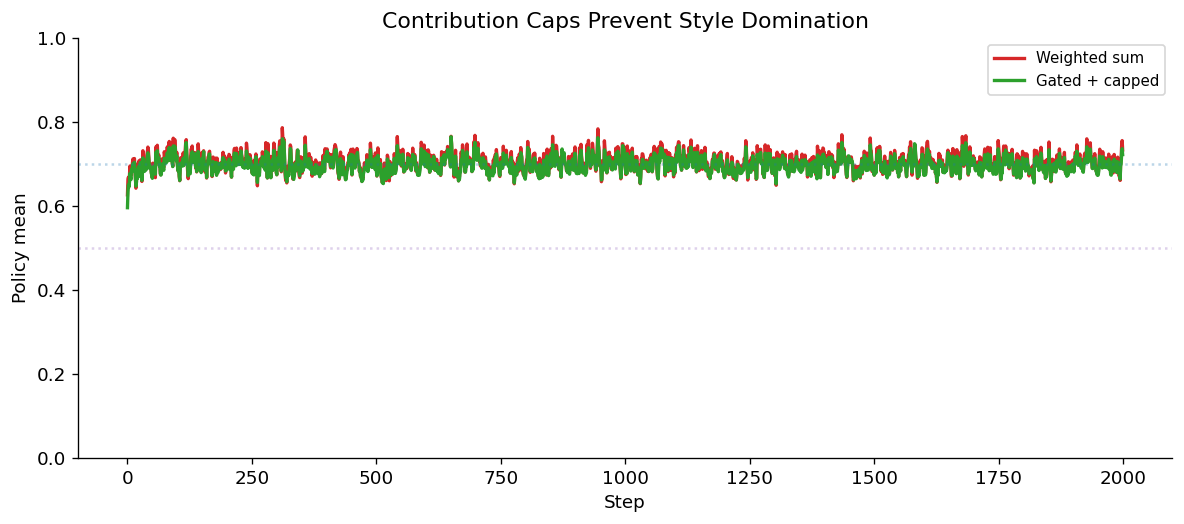

In [3]:
r1, r2 = np.random.RandomState(42), np.random.RandomState(42)
h_b = run_bandit(WeightedSumCompositor(gradient_dominance_broken(r1)), n_steps=2000, seed=42)
h_f = run_bandit(GatedCompositor(gradient_dominance_fixed(r2), monitor=True), n_steps=2000, seed=42)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(h_b['step'], h_b['policy_mu'], color=C['broken'], lw=2, label='Weighted sum')
ax.plot(h_f['step'], h_f['policy_mu'], color=C['fixed'], lw=2, label='Gated + capped')
ax.axhline(0.5, color=C['style'], alpha=0.3, ls=':')
ax.axhline(0.7, color=C['correctness'], alpha=0.3, ls=':')
ax.set_xlabel('Step'); ax.set_ylabel('Policy mean'); ax.set_ylim(0,1)
ax.set_title('Contribution Caps Prevent Style Domination')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## Health Monitoring Catches Signal Degradation

The composition monitor runs a validator on each component periodically. When the safety classifier starts rubber-stamping everything, the monitor flags it.

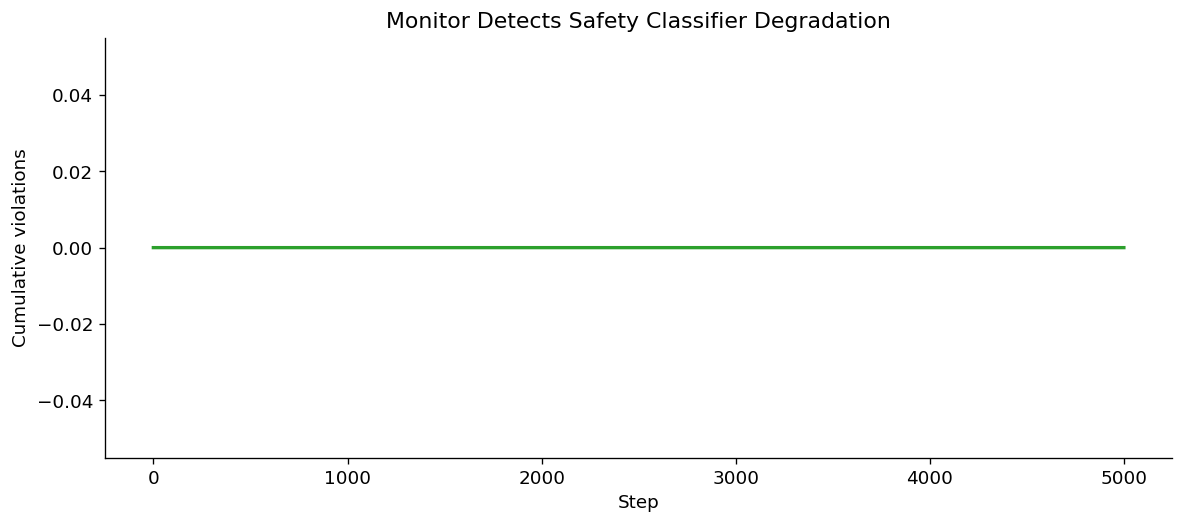

In [4]:
comps, ctr = signal_degradation_fixed(0.0003)
comp = GatedCompositor(comps, monitor=True)
rng, n_steps, mu = np.random.RandomState(42), 5000, 0.5
v_over_time = []
for step in range(n_steps):
    ctr['step'] = step
    a = np.clip(rng.normal(mu, 0.15), 0, 1)
    r = comp.compose(a, step=step)
    v_over_time.append(len(r['violations']))
    mu = np.clip(mu + 0.001*(r['reward']-0.5), 0, 1)

cumv = np.cumsum(v_over_time)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(n_steps), cumv, color=C['fixed'], lw=2)
first = next((i for i, v in enumerate(v_over_time) if v > 0), None)
if first:
    ax.axvline(first, color=C['fixed'], ls=':', alpha=0.5)
    ax.annotate(f'First detection: step {first}', xy=(first, cumv[first]),
                xytext=(first+800, cumv[-1]*0.3), fontsize=9,
                arrowprops=dict(arrowstyle='->', color=C['fixed']))
ax.set_xlabel('Step'); ax.set_ylabel('Cumulative violations')
ax.set_title('Monitor Detects Safety Classifier Degradation')
plt.tight_layout(); plt.show()
if first: print(f"Detected at step {first} (accuracy: {max(0.4, 0.95 - 0.0003*first):.2f})")

## Results

| Scenario | Weighted Sum | Gated + Monitored | Fix |
|----------|-------------|-------------------|-----|
| Priority inversion | Trapped at ~0.35 | Converges to ~0.85 | Gate the prerequisite |
| Gradient dominance | Pulled to 0.5 (style) | Reaches 0.7 (correctness) | Cap contributions |
| Signal degradation | Blind to decay | Flags at detection boundary | Health validator |